In [2]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
device = torch.device("gpu" if torch.cuda.is_available() else "cpu")

In [4]:
df = pd.read_csv('../data/newport_raw.csv', dtype=str)

In [5]:
df.columns = df.columns.str.lower()

In [6]:
visits_cols = [
  col for col in df.columns 
  if re.match(r'^visits_h\d+$', col)
]

df[visits_cols] = df[visits_cols].apply(
  pd.to_numeric, 
  errors='coerce'
)


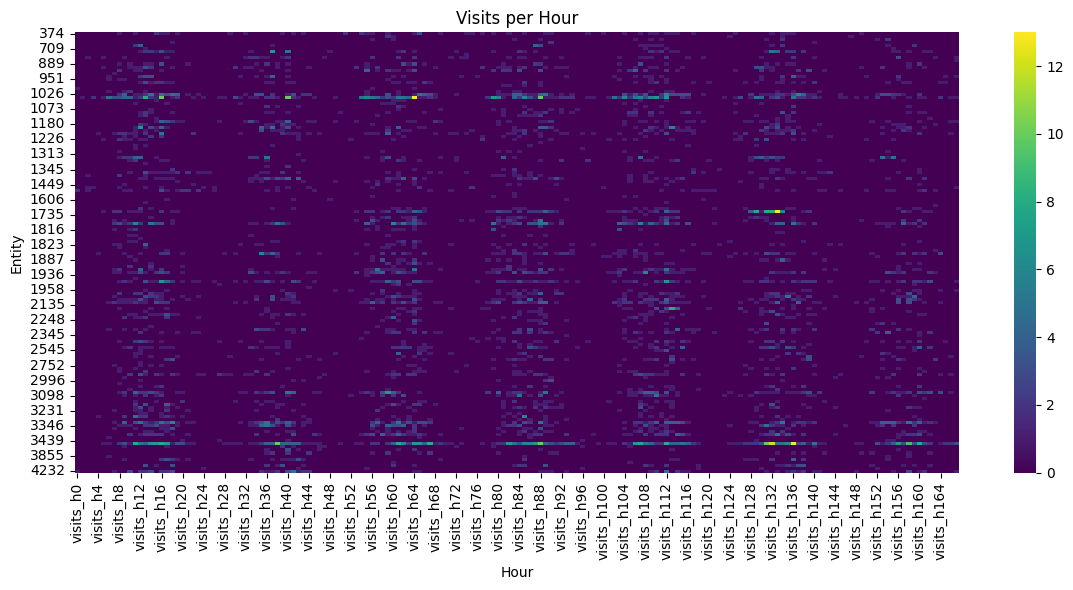

In [7]:

# Extract just the nonmissing visits data
visits_data = df[visits_cols].astype(float).dropna() 

# Heatmap of raw data
plt.figure(figsize=(12, 6))
sns.heatmap(visits_data, cmap='viridis', cbar=True)

plt.xlabel("Hour")
plt.ylabel("Entity")
plt.title("Visits per Hour")
plt.tight_layout()
plt.show()


In [8]:
tr = df.dropna(subset=visits_cols)

tr = tr.melt(
    id_vars=['prim_occ','sqmeters'],
    value_vars=visits_cols,
    var_name='hour_of_week',
    value_name='visits'
)

tr['sqmeters'] = tr['sqmeters'].astype('float64')

tr['hour_of_week'] = tr['hour_of_week'].str.extract(r'(\d+)').astype(int)
tr['hour'] = tr['hour_of_week'] % 24
tr['day'] = tr['hour_of_week'] // 24

tr['sin_hour'] = np.sin(2*np.pi*tr['hour']/24)
tr['cos_hour'] = np.cos(2*np.pi*tr['hour']/24)
tr['sin_dow'] = np.sin(2*np.pi*tr['day']/7)
tr['cos_dow'] = np.cos(2*np.pi*tr['day']/7)

tr['log_sqmeters'] = np.log1p(tr['sqmeters'])
tr['log_sqmeters'] = (tr['log_sqmeters']-tr['log_sqmeters'].mean())/tr['log_sqmeters'].std()

tr['x_prim_occ'] = tr['prim_occ'].astype('category').cat.codes
n_categories = tr['x_prim_occ'].nunique()

In [9]:
x_sin_dow = torch.tensor(tr['sin_dow'].values,dtype=torch.float32).unsqueeze(1).to(device)
x_cos_dow = torch.tensor(tr['cos_dow'].values,dtype=torch.float32).unsqueeze(1).to(device)
x_sin_hour = torch.tensor(tr['sin_hour'].values,dtype=torch.float32).unsqueeze(1).to(device)
x_cos_hour = torch.tensor(tr['cos_hour'].values,dtype=torch.float32).unsqueeze(1).to(device)

x_area = torch.tensor(tr['log_sqmeters'].values,dtype=torch.float32).unsqueeze(1).to(device)
x_type = torch.tensor(tr['x_prim_occ'].values,dtype=torch.long).to(device)

y = torch.tensor(tr['visits'].values,dtype=torch.float32).unsqueeze(1).to(device)

In [10]:
tr.describe()

,sqmeters,hour_of_week,visits,hour,day,sin_hour,cos_hour,sin_dow,cos_dow,log_sqmeters,x_prim_occ
count,24528.000000,24528.000000,24528.000000,24528.000000,24528.000000,2.452800e+04,2.452800e+04,2.452800e+04,2.452800e+04,2.452800e+04,24528.000000
mean,1340.308273,83.500000,0.208293,11.500000,3.000000,9.269964e-18,-9.501713e-17,-3.707986e-17,-3.707986e-17,-1.081254e-15,6.917808
std,2153.612779,48.497552,0.705760,6.922328,2.000041,7.071212e-01,7.071212e-01,7.071212e-01,7.071212e-01,1.000000e+00,3.815165
min,92.324590,0.000000,0.000000,0.000000,0.000000,-1.000000e+00,-1.000000e+00,-9.749279e-01,-9.009689e-01,-2.007266e+00,0.000000
25%,337.067170,41.750000,0.000000,5.750000,1.000000,-7.071068e-01,-7.071068e-01,-7.818315e-01,-9.009689e-01,-7.433648e-01,4.000000
50%,641.355745,83.500000,0.000000,11.500000,3.000000,6.123234e-17,-6.123234e-17,0.000000e+00,-2.225209e-01,-1.130670e-01,8.000000
75%,1394.978400,125.250000,0.000000,17.250000,5.000000,7.071068e-01,7.071068e-01,7.818315e-01,6.234898e-01,6.491148e-01,10.000000
max,14440.208000,167.000000,13.000000,23.000000,6.000000,1.000000e+00,1.000000e+00,9.749279e-01,1.000000e+00,2.943382e+00,12.000000


In [15]:
class Net(nn.Module):
    def __init__(self, n_categories):
        super().__init__()

        self.type_emb = nn.Embedding(n_categories, 6)

        self.net = nn.Sequential(
            nn.Linear(4+1+6, 128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,1)
        )

    def forward(self,x_sin_dow,x_cos_dow,x_sin_hour,x_cos_hour,x_area,x_type):
        emb = self.type_emb(x_type)
        x = torch.cat([x_sin_dow,x_cos_dow,x_sin_hour,x_cos_hour,x_area,emb],dim=1)
        return self.net(x)  # log-rate
    

In [18]:
model = Net(n_categories).to(device)
loss_fn = torch.nn.PoissonNLLLoss(log_input=True, full=False)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [20]:
batch_size = 512
epochs = 200

for epoch in range(epochs):
    perm = torch.randperm(len(y),device=device)
    loss_epoch = 0

    for i in range(0,len(y),batch_size):
        idx = perm[i:i+batch_size]

        log_lambda = model(
            x_sin_dow[idx],
            x_cos_dow[idx],
            x_sin_hour[idx],
            x_cos_hour[idx],
            x_area[idx],
            x_type[idx]
        )

        loss = loss_fn(log_lambda,y[idx])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_epoch += loss.item()*len(idx)

    loss_epoch /= len(y)

    if epoch%10==0:
        print(epoch,loss_epoch)

0 0.28137359275820983
10 0.27890590766404705
20 0.27597849227522064
30 0.27376180873613926
40 0.27366954667538657
50 0.2720835375303703
60 0.26939777393241526
70 0.2667326970731831
80 0.2643440134060282
90 0.26676287568634194
100 0.26132211612084294
110 0.2631204743752352
120 0.26160013722346953
130 0.2572277173720694
140 0.257114971444176
150 0.256249004147524
160 0.2518718263155016
170 0.2523388975364899
180 0.2522681714931657
190 0.2483666624924908


In [13]:
len(y)

24528

In [ ]:
model.eval()
with torch.no_grad():
    pred = (model(
            x_sin_dow,
            x_cos_dow,
            x_sin_hour,
            x_cos_hour,
            x_area,
            x_type)
            .detach()
            .cpu()
            .squeeze()
            .numpy())
    obs = y.detach().cpu().squeeze().numpy()




In [14]:
np.exp(pred)

NameError: name 'pred' is not defined

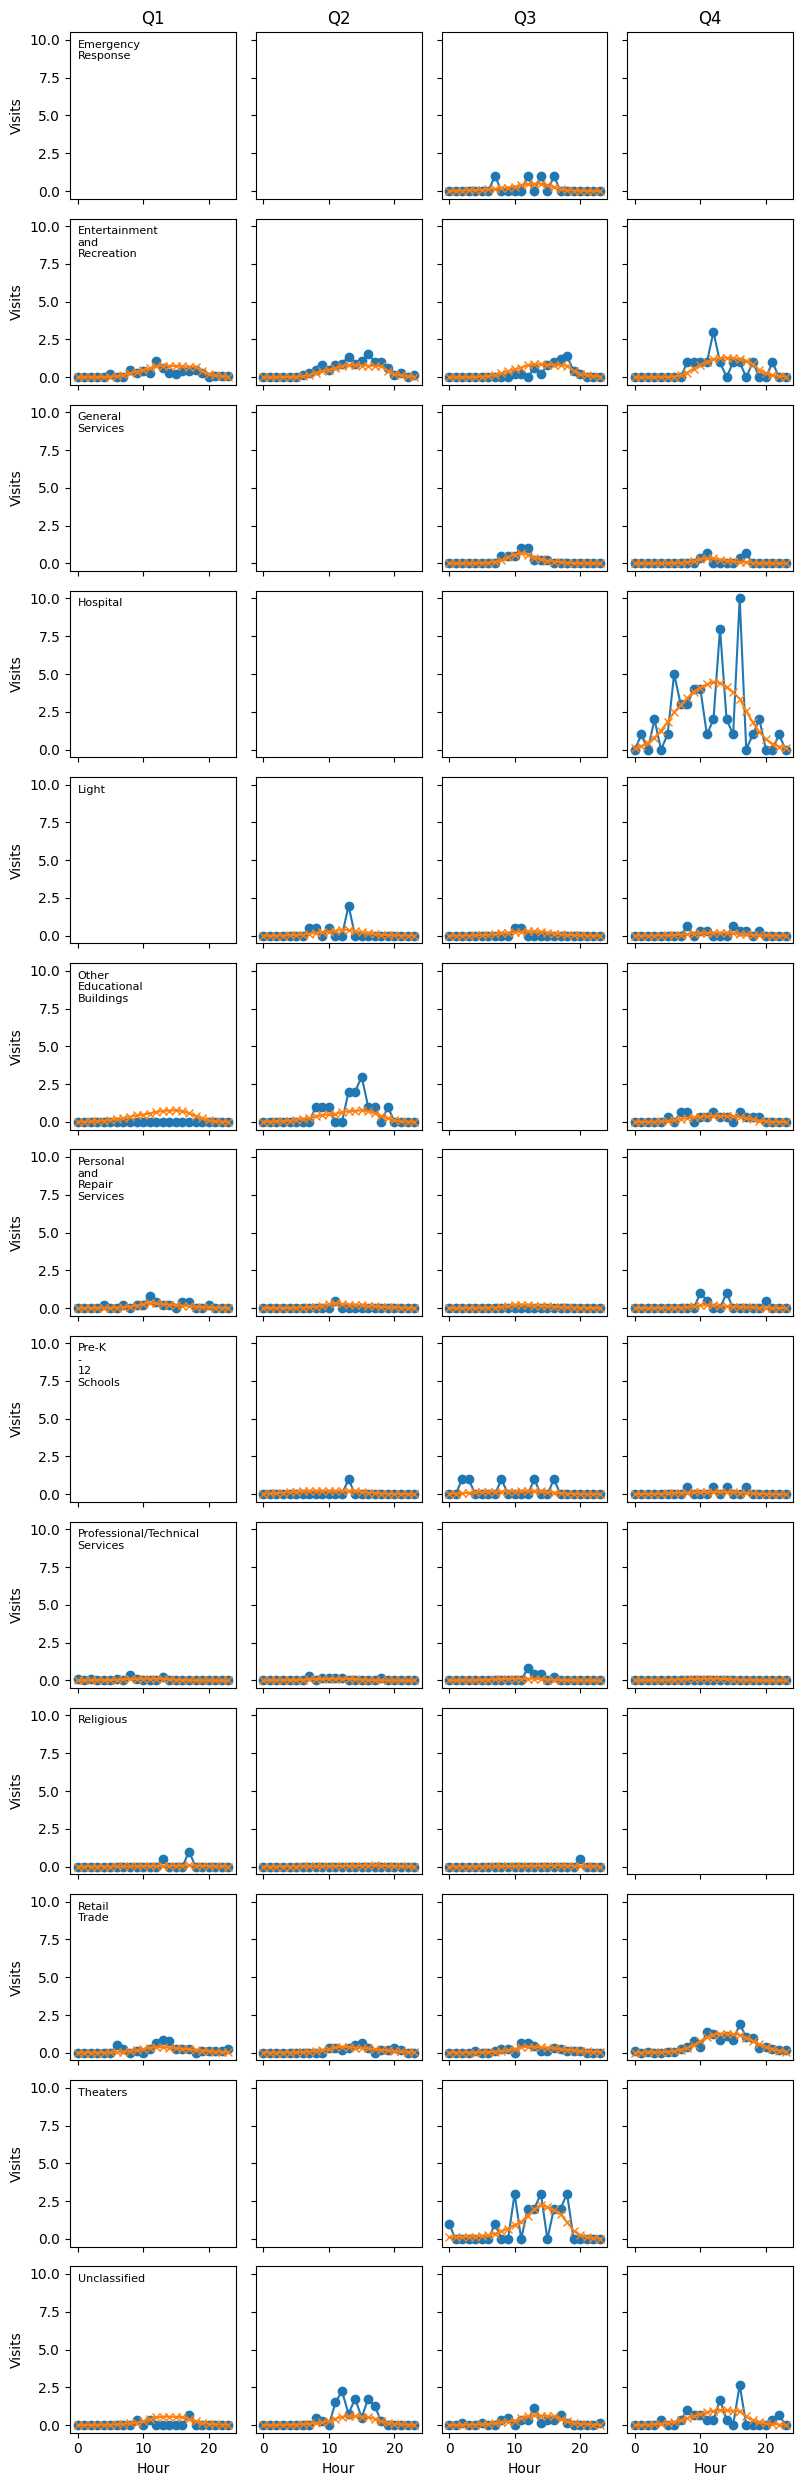

In [ ]:
# Parameters
day = 'Mon'
quartiles = range(4)
types = sorted(df_pred['type'].dropna().unique())
n_types = len(types)

# Set up plot grid
fig, axes = plt.subplots(n_types, 4, figsize=(8, 2 * n_types), sharex=True, sharey=True)
axes = np.atleast_2d(axes)  # ensures 2D shape even if n_types == 1

for row, btype in enumerate(types):
    for col, q in enumerate(quartiles):
        ax = axes[row, col]
        mask = (
            (df_pred['type'] == btype) &
            (df_pred['day'] == day) &
            (df_pred['sq_q'] == q)
        )
        sub = df_pred[mask]

        if not sub.empty:
            grp = sub.groupby('hour', observed=True)[['obs', 'pred']].mean()
            ax.plot(grp.index, grp['obs'],  marker='o', label='Observed')
            ax.plot(grp.index, grp['pred'], marker='x', label='Predicted')

        if col == 0:
            ax.set_ylabel("Visits")
        if row == n_types - 1:
            ax.set_xlabel("Hour")
        if row == 0:
            ax.set_title(f"Q{q+1}")

    # Add building type label inside leftmost subplot
    left_ax = axes[row, 0]
    label = '\n'.join(btype.split())
    left_ax.text(
        x=0, y=10, s=label,
        ha='left', va='top',
        fontsize=8, color='black',
        transform=left_ax.transData
    )

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


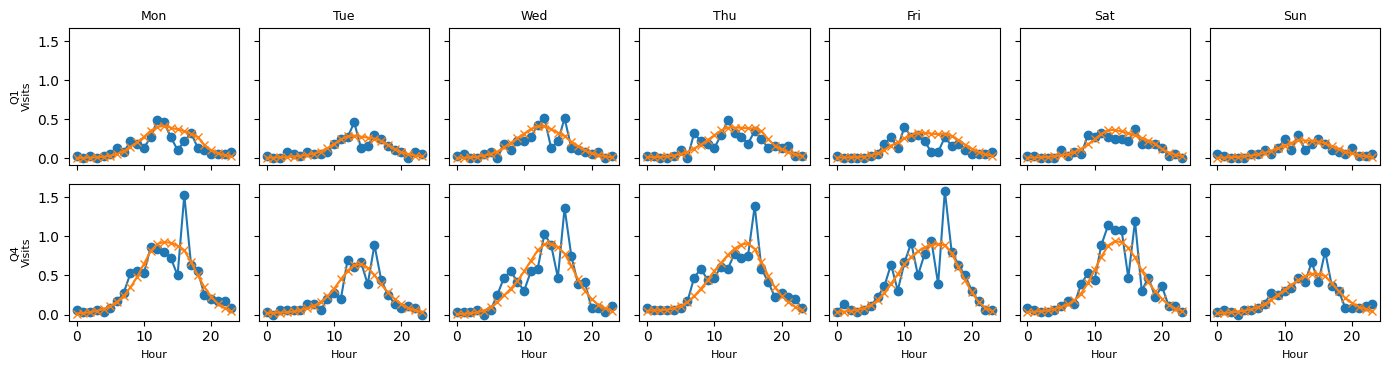

In [ ]:
# Parameters
quartiles = [0, 3]  # Q1 and Q4
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Set up plot grid: 2 rows (Q1 and Q4), 7 columns (days)
fig, axes = plt.subplots(2, 7, figsize=(14, 4), sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for row, q in enumerate(quartiles):
    for col, day in enumerate(days):
        ax = axes[row, col]
        mask = (
            (df_pred['day'] == day) &
            (df_pred['sq_q'] == q)
        )
        sub = df_pred[mask]

        if not sub.empty:
            grp = sub.groupby('hour', observed=True)[['obs', 'pred']].mean()
            ax.plot(grp.index, grp['obs'], marker='o', label='Observed')
            ax.plot(grp.index, grp['pred'], marker='x', label='Predicted')

        if col == 0:
            ax.set_ylabel(f"Q{q+1}\nVisits", fontsize=8)
        if row == 1:
            ax.set_xlabel("Hour", fontsize=8)
        if row == 0:
            ax.set_title(day, fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
# Save the model weights
torch.save(model.state_dict(), 'model_weights.pth')

In [ ]:
# Demo of loading model
# note need the Net() class definition to load the model
model_loaded = Net()
model_loaded.load_state_dict(torch.load('model_weights.pth', map_location='cpu'))
model_loaded.eval() 

with torch.no_grad():
    sample_preds = model_loaded(x_hour, x_area, x_day, x_type)

print("Sample predictions:", sample_preds[:5])

Sample predictions: tensor([[0.0014],
        [0.0101],
        [0.0033],
        [0.0005],
        [0.0156]])
